# Question 2: Decision Tree Building (Entropy & Information Gain) 

## 1. Difference between Entropy and Gini Index

**Answer:**

Entropy and Gini Index are impurity measures used in decision trees to decide the best feature for splitting the dataset.

| Aspect | Entropy | Gini Index |
|------|------|------|
| Definition | Measures the randomness or disorder in the dataset | Measures the probability of misclassifying a randomly chosen sample |
| Formula | Entropy(S) = − Σ pᵢ log₂(pᵢ) | Gini(S) = 1 − Σ (pᵢ²) |
| Range | 0 to 1 | 0 to 0.5 (for binary classification) |
| Interpretation | Higher value means more impurity | Higher value means more impurity |
| Usage | Used in ID3 algorithm | Used in CART algorithm |
| Computation | Slightly slower because of logarithm | Faster to compute |

Both methods aim to **reduce impurity and create better splits in the decision tree**.

---

## 2. Why do decision trees overfit?

**Answer:**

Decision trees tend to **overfit** when they grow very deep and start learning the noise in the training data instead of the actual patterns.

Reasons include:
- The tree keeps splitting until each leaf node contains very few samples.
- It memorizes the training data rather than generalizing from it.
- Small variations in the data can create very different trees.

As a result, the model performs well on training data but poorly on new unseen data.

---

## 3. What is pruning?

**Answer:**

Pruning is the process of **reducing the size of a decision tree by removing unnecessary branches** that do not improve prediction accuracy.

The goal of pruning is to **prevent overfitting and improve generalization**.

Types of pruning:

- **Pre-pruning (Early stopping)**  
  Stops the tree growth before it becomes too complex.

- **Post-pruning**  
  Builds the full tree first and then removes branches that provide little predictive power.

Pruning helps create a **simpler and more robust model**.

---

## 4. What happens if tree depth increases?

**Answer:**

If the **depth of the decision tree increases**, the model becomes more complex.

Effects include:
- The tree captures more detailed patterns in the training data.
- Training accuracy increases.
- The risk of **overfitting increases**.

A very deep tree may memorize the training data and perform poorly on new data. Therefore, controlling tree depth is important for achieving a good balance between **bias and variance**.

In [49]:
import pandas as pd 
import numpy as np
from sklearn.tree import DecisionTreeClassifier


In [50]:
df = pd.read_csv('synthetic_buy_dataset.csv')
df

,Age,Income,Student,Buy
0,Middle,Low,Yes,Yes
1,Senior,Medium,No,Yes
2,Senior,Medium,No,Yes
3,Middle,Low,No,Yes
4,Young,Low,No,Yes
...,...,...,...,...
495,Middle,High,No,Yes
496,Middle,Low,No,No
497,Young,High,No,Yes
498,Senior,Low,Yes,Yes


In [51]:
def entropy(col):
    p = col.value_counts(normalize=True)
    return -np.sum(p*np.log2(p))

dataset_entropy = entropy(df['Buy'])
print("Dataset Entropy:",dataset_entropy)

for feature in ['Age','Income','Student']:
    
    weighted_entropy = 0
    
    for val in df[feature].unique():
        subset = df[df[feature]==val]
        weight = len(subset)/len(df)
        weighted_entropy += weight*entropy(subset['Buy'])
        
    ig = dataset_entropy - weighted_entropy
    
    print(feature,"Information Gain:",ig)

Dataset Entropy: 0.9858150371789198
Age Information Gain: 0.044145655274039686
Income Information Gain: 0.0021589744715502235
Student Information Gain: 0.011392514221947758


In [52]:
X= df[['Age', 'Income', 'Student']]
y = df['Buy']

In [53]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in X.columns:
    X[col] = encoder.fit_transform(X[col])

y = encoder.fit_transform(y)

In [54]:
model = DecisionTreeClassifier(criterion='entropy')
model.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cu

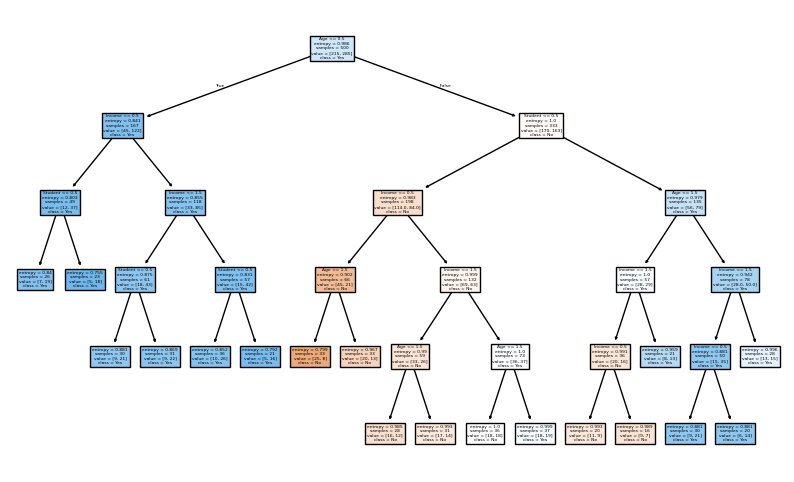

In [55]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plot_tree(model,
          feature_names=['Age','Income','Student'],
          class_names=['No','Yes'],
          filled=True)

plt.show()

In [56]:
da = np.array([['Young','High','No']])
da = encoder.fit_transform(da.flatten()).reshape(1,-1)

prediction = model.predict(da)

print("Prediction:", prediction)

Prediction: [1]


c:\Users\indiranivas_s\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
